# Tutorial: Quantum Control Optimisation with RL  
## Implementing PPO and TD3 for GHZ State Preparation


This hands-on guide demonstrates implementation of RL agents for optimising quantum state preparation fidelity. We focus on creating a 3-qubit GHZ state:

$$\frac{|000\rangle +|111\rangle}{\sqrt{2}}$$

using two cutting-edge RL algorithms: **PPO** (on-policy) and **TD3** (off-policy).

First we import the required libraries. Where we can highlight create_parametrized_circuit, function that allow us create a quantum circuit and that can be modified easily and the optimiser: RLQuantumOptimiserPPO and RLQuantumOptimiserTD3.


**Key Implementation Tools:**
- `create_parametrized_circuit(num_qubits, thetas, initial_state, entanglement='CX')`:  
  Constructs tunable quantum circuits with:
  - Parametrised rotation gates (X, Y, Z)
  - Entangling layers
  - Customisable ansatz architecture

- **RL Optimisers**:
Allow creating RL optimisers with tunable hyperparameters for PPO and TD3 algorithms.

Note: The hyperparameters that you will find in this notebook have not been optimised.

In [ ]:
import numpy as np
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(os.path.join(parent_dir, 'src/utils/'))
sys.path.append(os.path.join(parent_dir, 'src/rl/'))
from functions import CustomEncoder
from circuit_utils import create_parametrized_circuit
utils_path = os.path.abspath(os.path.join(parent_dir, '../src/'))
sys.path.append(utils_path)
import json
from optimisation_rl import RLQuantumOptimiserPPO, RLQuantumOptimiserTD3


First, we define the number of qubits of our problem, the number of angles, that in our case there are two parameters per qubits, the target and initial state.

In [2]:
# Define the quantum system parameters, including qubit count and parameter bounds.
num_qubits = 3
n_thetas = num_qubits * 2  # Each qubit has two tunable parameters
param_bounds = [[0, 2 * np.pi] for _ in range(n_thetas)]

target_state = np.array([1, 0, 0, 0, 0, 0, 0, 1]) / np.sqrt(2)
initial_state = np.array([1, 0, 0, 0, 0, 0, 0, 0])



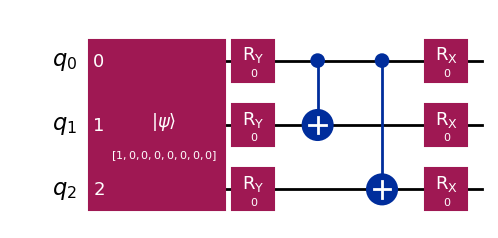

In [3]:
qc = create_parametrized_circuit(num_qubits, np.zeros(n_thetas)[np.newaxis,:], initial_state)
qc.draw('mpl')


## Training and evaluating PPO

In this section, we train and evaluate the PPO algorithm. We start by defining the necessary hyperparameters and specifying the number of times we will run the same architecture to ensure consistency in our results.

In [ ]:
hyperparams = {
    'learning_rate': 0.01,
    'n_steps': 20,
    'batch_size': 10,
    'gae_lambda': 0.95,
    'gamma': 0.99,
    'n_epochs': 20,
    'clip_range': 0.3,
    'ent_coef': 0.01,
    'verbose':0,
    'total_timesteps':200, #Number of iteration = Number of angles sets to test
    }

n_run = 3

metrics = {'history_best_fidelity_runs':[],
           'history_best_thetas_runs':[],
           'best_fidelity_runs':[],
           'best_thetas_runs': []}
for iter_run in range(n_run):
    print('run ', iter_run+1)

    optimiser = RLQuantumOptimiserPPO(create_parametrized_circuit, 
                                n_thetas=n_thetas, 
                                initial_state=initial_state, 
                                target_state=target_state, 
                                num_qubits=num_qubits,
                                hyperparams=hyperparams)
    
    optimal_params, fidelity, info = optimiser.optimise()
    print("Optimal parameters found:", optimal_params)
    print("Optimal fidelity found:", fidelity)

    log_best_thetas = np.array(info['best_log']['thetas'] )
    log_best_fidelity = np.array(info['best_log']['fidelity'] )

    metrics['history_best_thetas_runs'].append(log_best_thetas)
    metrics['history_best_fidelity_runs'].append(log_best_fidelity)
    metrics['best_thetas_runs'].append(optimal_params)
    metrics['best_fidelity_runs'].append(fidelity)
   


run  1
Optimal parameters found: [1.5039141  0.         0.21591765 0.         0.         0.        ]
Optimal fidelity found: 0.987285190578285
run  2
Optimal parameters found: [1.271889   0.         0.         0.02952927 0.         0.        ]
Optimal fidelity found: 0.9776162628274137
run  3
Optimal parameters found: [0.95841867 0.17181727 0.         0.1996718  0.10160249 0.        ]
Optimal fidelity found: 0.8911967166949615


We can save our results for later analysis

In [5]:

if True:
    name_output_file = "example_results_3ghz_ppo_NEW"
    
    data_plot = {'history_best_fidelity_runs':metrics['history_best_fidelity_runs'],
                'best_thetas_runs': metrics['best_thetas_runs'],
                'best_fidelity_runs':metrics['best_fidelity_runs']} 
    with open("../results/" + name_output_file + ".json", "w") as outfile: 
        json.dump(data_plot, outfile, cls=CustomEncoder)


We plot the results for PPO

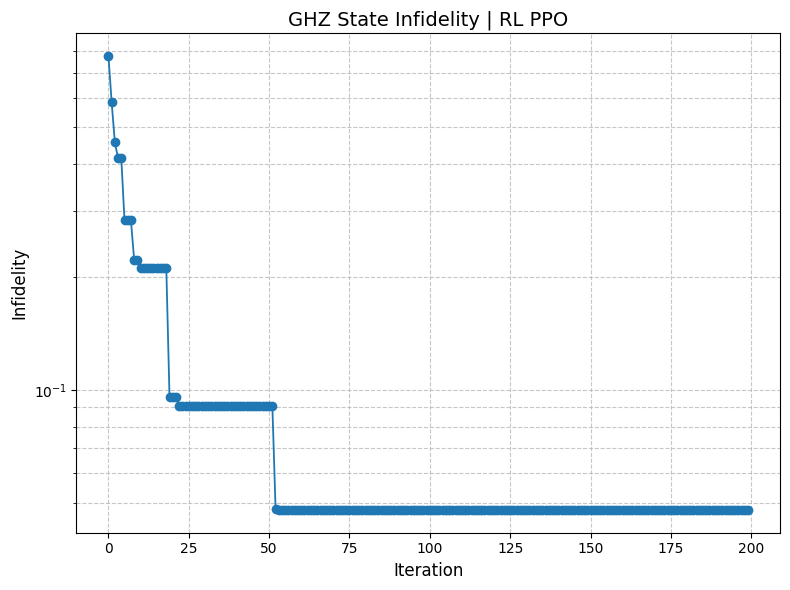

Mean Best Infidelity:  0.04796727663311329


In [6]:
import matplotlib.pylab as plt

plt.figure(figsize=(8, 6)) 
plt.plot(np.arange(hyperparams['total_timesteps'],dtype=int),1-np.mean(metrics['history_best_fidelity_runs'],0),
          marker='o', linestyle='-', linewidth=1.3)
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Iteration', fontsize=12)
plt.yscale('log')
plt.title('GHZ State Infidelity | RL PPO', fontsize=14)
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print('Mean Best Infidelity: ', 1-np.mean(metrics['best_fidelity_runs']))

## Training and evaluating TD3  

Next, we apply the same process to the TD3 algorithm. We define the necessary hyperparameters and specify the number of runs for the same architecture to ensure consistency in our results.  

In [ ]:
hyperparams = {
    'learning_rate': 0.000001,
    'batch_size': 10,
    'gamma': 0.99,
    'noise_std': 0.001,
    'verbose':0,
    'total_timesteps':200,
    }

n_run = 3

metrics = {'history_best_fidelity_runs':[],
           'history_best_thetas_runs':[],
           'best_fidelity_runs':[],
           'best_thetas_runs': []}
for iter_run in range(n_run):
    print('run ', iter_run+1)

    optimiser = RLQuantumOptimiserTD3(create_parametrized_circuit, 
                                n_thetas=n_thetas, 
                                initial_state=initial_state, 
                                target_state=target_state, 
                                num_qubits=num_qubits,
                                hyperparams=hyperparams)

    optimal_params, fidelity, info = optimiser.optimise()

    print("Optimal parameters found:", optimal_params)
    print("Optimal fidelity found:", fidelity)

    log_best_thetas = np.array(info['best_log']['thetas'] )
    log_best_fidelity = np.array(info['best_log']['fidelity'] )

    metrics['history_best_thetas_runs'].append(log_best_thetas)
    metrics['history_best_fidelity_runs'].append(log_best_fidelity)
    metrics['best_thetas_runs'].append(optimal_params)
    metrics['best_fidelity_runs'].append(fidelity)
   

run  1
Optimal parameters found: [0.83736104 6.249137   2.0403244  2.5952642  3.5980692  5.523418  ]
Optimal fidelity found: 0.5556942898654348
run  2
Optimal parameters found: [1.1869212  5.6606216  2.9012492  2.6568294  3.3463953  0.14356184]
Optimal fidelity found: 0.7948443804023622
run  3
Optimal parameters found: [1.4850903 3.0347662 2.945776  2.8914936 0.8700471 5.951827 ]
Optimal fidelity found: 0.7842260042563588


In [8]:
if True:
    name_output_file = "example_results_3ghz_td3_NEW"
    
    data_plot = {'history_best_fidelity_runs':metrics['history_best_fidelity_runs'],
                'best_thetas_runs': metrics['best_thetas_runs'],
                'best_fidelity_runs':metrics['best_fidelity_runs']} 
    with open("../results/" + name_output_file + ".json", "w") as outfile: 
        json.dump(data_plot, outfile, cls=CustomEncoder)


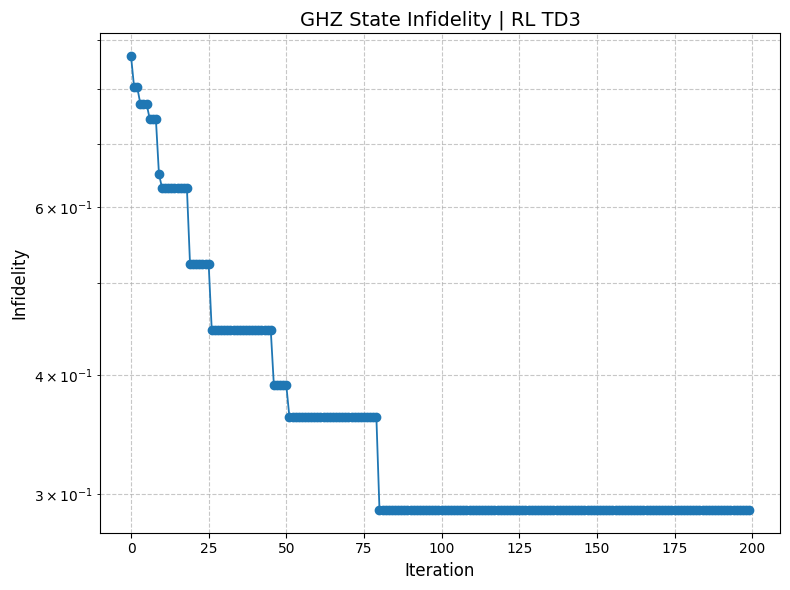

Mean Best Infidelity:  0.2884117751586147


In [9]:
plt.figure(figsize=(8, 6)) 
plt.plot(np.arange(hyperparams['total_timesteps'],dtype=int),1-np.mean(metrics['history_best_fidelity_runs'],0),
          marker='o', linestyle='-', linewidth=1.3)
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Iteration', fontsize=12)
plt.yscale('log')
plt.title('GHZ State Infidelity | RL TD3', fontsize=14)
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print('Mean Best Infidelity: ', 1-np.mean(metrics['best_fidelity_runs']))